# Emotion Classification Fine-tuning
Notebook Kaggle dùng `bhadresh-savani/bert-base-uncased-emotion` trên `dair-ai/emotion`.

In [1]:
!pip -q install transformers datasets accelerate scikit-learn matplotlib seaborn

In [2]:
import os, math, random, warnings, logging
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "bhadresh-savani/bert-base-uncased-emotion"
DATASET_NAME = "dair-ai/emotion"
LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]
NUM_LABELS = 6
MAX_LENGTH = 128
OUTPUT_DIR = "/kaggle/working/emotion_finetune_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
print('Loading dataset...')
ds = load_dataset(DATASET_NAME)
print(ds)
print('Train size:', len(ds['train']))
print('Validation size:', len(ds['validation']))
print('Test size:', len(ds['test']))

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Train size: 16000
Validation size: 2000
Test size: 2000


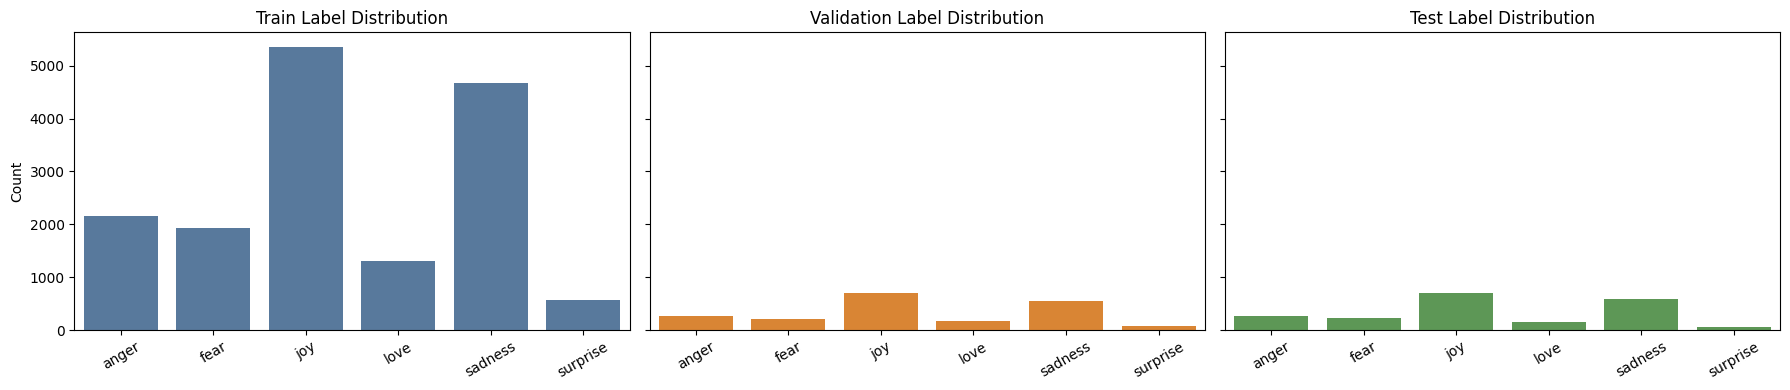

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {i: name for i, name in enumerate(LABEL_NAMES)}

train_counts = pd.Series(ds["train"]["label"]).map(label_map).value_counts().sort_index()
val_counts = pd.Series(ds["validation"]["label"]).map(label_map).value_counts().sort_index()
test_counts = pd.Series(ds["test"]["label"]).map(label_map).value_counts().sort_index()

fig, ax = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=ax[0], color="#4C78A8")
ax[0].set_title("Train Label Distribution")
ax[0].set_xlabel("")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(x=val_counts.index, y=val_counts.values, ax=ax[1], color="#F58518")
ax[1].set_title("Validation Label Distribution")
ax[1].set_xlabel("")
ax[1].tick_params(axis="x", rotation=30)

sns.barplot(x=test_counts.index, y=test_counts.values, ax=ax[2], color="#54A24B")
ax[2].set_title("Test Label Distribution")
ax[2].set_xlabel("")
ax[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/kaggle/working/label_distribution.png", dpi=150)
plt.show()

In [5]:
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = ds['train'].rename_column('label', 'labels').map(tokenize_fn, batched=True)
val_ds = ds['validation'].rename_column('label', 'labels').map(tokenize_fn, batched=True)
test_ds = ds['test'].rename_column('label', 'labels').map(tokenize_fn, batched=True)

train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenization done.')

Loading tokenizer...


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization done.


In [6]:
print('Loading model...')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)}
)

counts = np.bincount(ds['train']['label'], minlength=NUM_LABELS)
weights = counts.sum() / (NUM_LABELS * np.clip(counts, 1, None))
class_weights = torch.tensor(weights, dtype=torch.float)
print('Class weights:', class_weights.tolist())

Loading model...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Class weights: [0.5715101957321167, 0.49732688069343567, 2.044989824295044, 1.2351397275924683, 1.3766993284225464, 4.662004470825195]


In [7]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=0.05
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "precision_macro": float(precision_score(labels, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(labels, preds, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
    }

In [9]:
steps_per_epoch = math.ceil(len(train_ds) / 16)
training_args = TrainingArguments(
    disable_tqdm=False,
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    learning_rate=5e-6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=max(50, int(0.06 * steps_per_epoch * 4)),
    lr_scheduler_type='cosine',
    eval_strategy='steps',
    eval_steps=20,
    save_strategy='steps',
    save_steps=20,
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Training...')
trainer.train()
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history[log_history["loss"].notna()][
    ["step", "epoch", "loss", "learning_rate"]
].reset_index(drop=True)

eval_log = log_history[log_history["eval_loss"].notna()][
    ["step", "epoch", "eval_loss", "eval_accuracy",
     "eval_precision_macro", "eval_recall_macro",
     "eval_f1_macro", "eval_f1_weighted"]
].reset_index(drop=True)

print("=== Train log ===")
print(train_log)
print("\n=== Eval log ===")
print(eval_log)

train_log.to_csv("/kaggle/working/train_log.csv", index=False)
eval_log.to_csv("/kaggle/working/eval_log.csv", index=False)

Training...


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
20,No log,0.790081,0.939500,0.913816,0.923541,0.918175,0.939770
40,0.652901,0.772191,0.937000,0.906099,0.926677,0.915532,0.937568
60,0.676506,0.745156,0.936000,0.901350,0.930203,0.914549,0.936745
80,0.623975,0.693355,0.931500,0.886457,0.937075,0.908116,0.932967
100,0.594775,0.643162,0.925500,0.874483,0.933337,0.898165,0.927608
120,0.594775,0.598145,0.913500,0.853616,0.930244,0.880091,0.917738
140,0.547024,0.563942,0.926000,0.874968,0.933424,0.897286,0.928216
160,0.501487,0.543312,0.929500,0.882493,0.931683,0.902548,0.931042
180,0.460144,0.531996,0.934000,0.893340,0.930270,0.909408,0.934864
200,0.453249,0.518015,0.935000,0.895231,0.933729,0.912430,0.935894


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

=== Train log ===
    step  epoch      loss  learning_rate
0     25   0.05  0.652901   5.000000e-07
1     50   0.10  0.676506   1.020833e-06
2     75   0.15  0.623975   1.541667e-06
3    100   0.20  0.594775   2.062500e-06
4    125   0.25  0.547024   2.583333e-06
5    150   0.30  0.501487   3.104167e-06
6    175   0.35  0.460144   3.625000e-06
7    200   0.40  0.453249   4.145833e-06
8    225   0.45  0.484799   4.666667e-06
9    250   0.50  0.468738   4.999371e-06
10   275   0.55  0.435880   4.991022e-06
11   300   0.60  0.461081   4.972998e-06
12   325   0.65  0.438747   4.945369e-06

=== Eval log ===
    step  epoch  eval_loss  eval_accuracy  eval_precision_macro  \
0     20   0.04   0.790081         0.9395              0.913816   
1     40   0.08   0.772191         0.9370              0.906099   
2     60   0.12   0.745156         0.9360              0.901350   
3     80   0.16   0.693355         0.9315              0.886457   
4    100   0.20   0.643162         0.9255              

In [10]:
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best metric:', trainer.state.best_metric)

print('Validation results:')
val_res = trainer.evaluate(val_ds)
for k, v in val_res.items():
    if k.startswith('eval_'):
        print(k, round(v, 4))

Best checkpoint: /kaggle/working/emotion_finetune_v2/checkpoint-280
Best metric: 0.5031322836875916
Validation results:


eval_loss 0.5032
eval_accuracy 0.9415
eval_precision_macro 0.9077
eval_recall_macro 0.9408
eval_f1_macro 0.9221
eval_f1_weighted 0.9421
eval_runtime 4.3513
eval_samples_per_second 459.635
eval_steps_per_second 7.354


In [11]:
print("\n" + "="*60)
print("ĐÁNH GIÁ TRÊN TEST SET")
print("="*60)

test_out = trainer.predict(test_ds)
logits_test = test_out.predictions
labels_test = test_out.label_ids
preds_test = np.argmax(logits_test, axis=-1)
probs_test = torch.softmax(torch.tensor(logits_test, dtype=torch.float32), dim=-1).numpy()

test_accuracy = accuracy_score(labels_test, preds_test)
test_precision = precision_score(labels_test, preds_test, average="macro", zero_division=0)
test_recall = recall_score(labels_test, preds_test, average="macro", zero_division=0)
test_f1 = f1_score(labels_test, preds_test, average="macro", zero_division=0)
test_f1_weighted = f1_score(labels_test, preds_test, average="weighted", zero_division=0)

print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Precision Macro    : {test_precision:.4f}")
print(f"Recall Macro       : {test_recall:.4f}")
print(f"F1 Macro           : {test_f1:.4f}")
print(f"F1 Weighted        : {test_f1_weighted:.4f}")

results_df = pd.DataFrame([{
    "accuracy": test_accuracy,
    "precision_macro": test_precision,
    "recall_macro": test_recall,
    "f1_macro": test_f1,
    "f1_weighted": test_f1_weighted
}])

results_df.to_csv("/kaggle/working/test_metrics.csv", index=False)
display(results_df)  # ← dùng display() thay vì chỉ gọi tên biến

print("\nClassification report:")
print(classification_report(labels_test, preds_test, target_names=LABEL_NAMES, digits=4))


ĐÁNH GIÁ TRÊN TEST SET
Accuracy           : 0.9290
Precision Macro    : 0.8688
Recall Macro       : 0.9052
F1 Macro           : 0.8844
F1 Weighted        : 0.9304


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,0.929,0.868779,0.905203,0.884431,0.930444



Classification report:
              precision    recall  f1-score   support

     sadness     0.9691    0.9707    0.9699       581
         joy     0.9788    0.9281    0.9527       695
        love     0.8077    0.9245    0.8622       159
       anger     0.9203    0.9236    0.9220       275
        fear     0.8940    0.8661    0.8798       224
    surprise     0.6429    0.8182    0.7200        66

    accuracy                         0.9290      2000
   macro avg     0.8688    0.9052    0.8844      2000
weighted avg     0.9337    0.9290    0.9304      2000



In [12]:
from itertools import product

# Thử các threshold từ 0.3 đến 0.7 cho lớp surprise và love
# Các lớp khác giữ nguyên 0.5
best_f1 = 0
best_threshold = [0.5] * NUM_LABELS

# Chỉ tinh chỉnh 2 lớp có precision thấp nhất: love (2), surprise (5)
for t_love, t_surprise in product(
    [0.3, 0.35, 0.4, 0.45, 0.5],
    [0.2, 0.25, 0.3, 0.35, 0.4]
):
    thresholds = [0.5, 0.5, t_love, 0.5, 0.5, t_surprise]
    adjusted_probs = probs_test * np.array(thresholds)
    preds_custom = np.argmax(adjusted_probs, axis=-1)
    f1 = f1_score(labels_test, preds_custom, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresholds

print("Best thresholds:", best_threshold)
print("Best F1 macro with threshold:", round(best_f1, 4))

# So sánh với kết quả gốc
preds_default = np.argmax(probs_test, axis=-1)
f1_default = f1_score(labels_test, preds_default, average="macro", zero_division=0)
print("F1 macro default (threshold=0.5):", round(f1_default, 4))

# In classification report với threshold tốt nhất
adjusted_probs_best = probs_test * np.array(best_threshold)
preds_best = np.argmax(adjusted_probs_best, axis=-1)
print(classification_report(labels_test, preds_best, target_names=LABEL_NAMES, digits=4))

Best thresholds: [0.5, 0.5, 0.5, 0.5, 0.5, 0.35]
Best F1 macro with threshold: 0.8924
F1 macro default (threshold=0.5): 0.8844
              precision    recall  f1-score   support

     sadness     0.9691    0.9707    0.9699       581
         joy     0.9788    0.9281    0.9527       695
        love     0.7989    0.9245    0.8571       159
       anger     0.9203    0.9236    0.9220       275
        fear     0.8933    0.8973    0.8953       224
    surprise     0.7162    0.8030    0.7571        66

    accuracy                         0.9320      2000
   macro avg     0.8794    0.9079    0.8924      2000
weighted avg     0.9354    0.9320    0.9330      2000



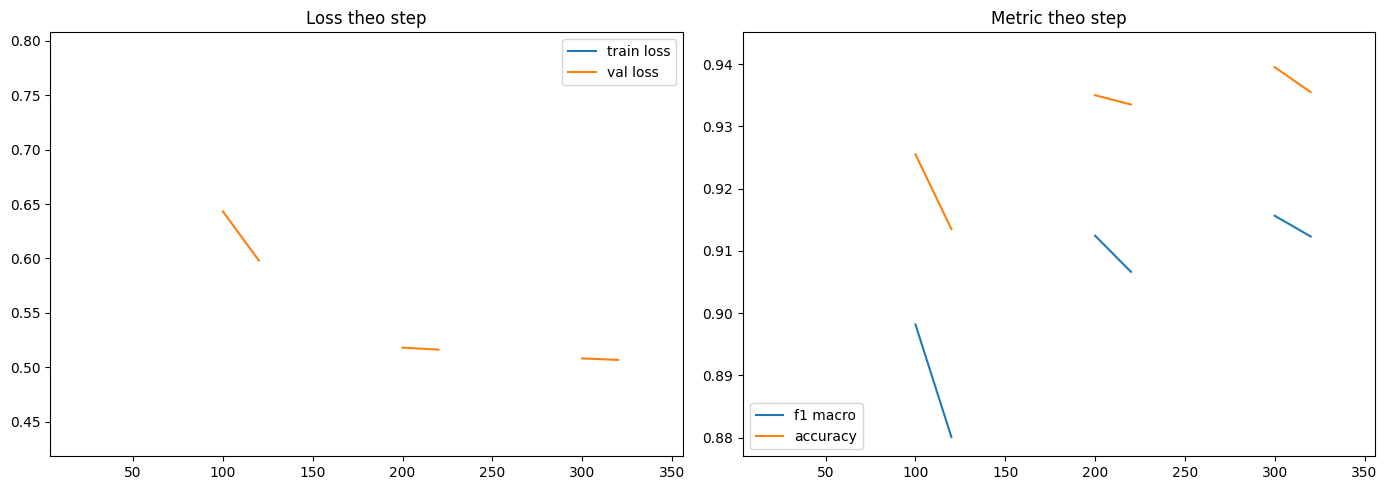

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

logs = pd.DataFrame(trainer.state.log_history)
logs = logs[[c for c in logs.columns if c in [
    "step","loss","eval_loss","eval_accuracy","eval_precision_macro",
    "eval_recall_macro","eval_f1_macro","eval_f1_weighted"
]]].copy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if "loss" in logs:
    ax[0].plot(logs["step"], logs["loss"], label="train loss")
if "eval_loss" in logs:
    ax[0].plot(logs["step"], logs["eval_loss"], label="val loss")
ax[0].set_title("Loss theo step")
ax[0].legend()

if "eval_f1_macro" in logs:
    ax[1].plot(logs["step"], logs["eval_f1_macro"], label="f1 macro")
if "eval_accuracy" in logs:
    ax[1].plot(logs["step"], logs["eval_accuracy"], label="accuracy")
ax[1].set_title("Metric theo step")
ax[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

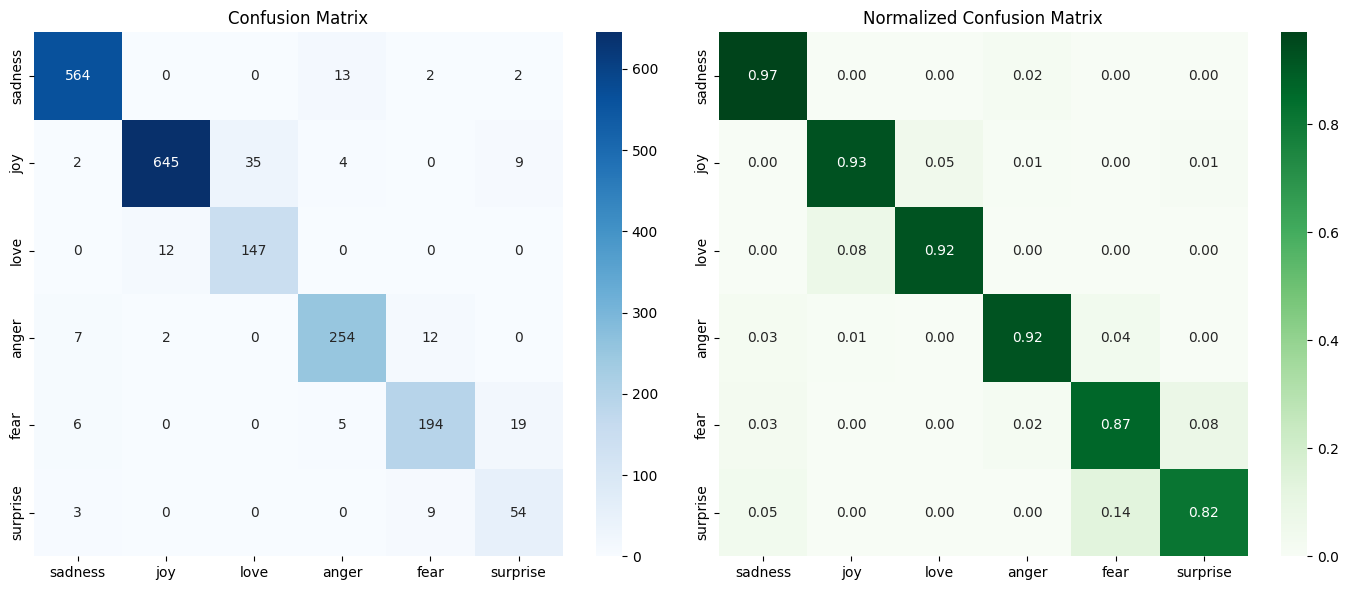

In [14]:
cm = confusion_matrix(labels_test, preds_test)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax[0])
ax[0].set_title("Confusion Matrix")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax[1])
ax[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150)
plt.show()

In [15]:
examples = [
    "I just got promoted at work and I'm so happy!",
    "I feel really sad and lonely today.",
    "I love spending time with my family on weekends.",
    "I'm furious because someone took credit for my idea.",
    "Wow, I didn't expect this surprise party at all!"
]

model.eval()
for i, text in enumerate(examples, 1):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))
    pred_label = LABEL_NAMES[pred_id]
    conf = probs[pred_id]

    print(f"\nVí dụ {i}")
    print("-" * 80)
    print(f"Text       : {text}")
    print(f"Pred label : {pred_label}  (confidence={conf:.4f})")
    top3 = np.argsort(probs)[::-1][:3]
    print("Top-3:")
    for j in top3:
        print(f"  - {LABEL_NAMES[j]}: {probs[j]:.4f}")


Ví dụ 1
--------------------------------------------------------------------------------
Text       : I just got promoted at work and I'm so happy!
Pred label : joy  (confidence=0.9360)
Top-3:
  - joy: 0.9360
  - surprise: 0.0190
  - sadness: 0.0137

Ví dụ 2
--------------------------------------------------------------------------------
Text       : I feel really sad and lonely today.
Pred label : sadness  (confidence=0.9082)
Top-3:
  - sadness: 0.9082
  - surprise: 0.0376
  - love: 0.0276

Ví dụ 3
--------------------------------------------------------------------------------
Text       : I love spending time with my family on weekends.
Pred label : joy  (confidence=0.7087)
Top-3:
  - joy: 0.7087
  - love: 0.1597
  - anger: 0.0505

Ví dụ 4
--------------------------------------------------------------------------------
Text       : I'm furious because someone took credit for my idea.
Pred label : anger  (confidence=0.9571)
Top-3:
  - anger: 0.9571
  - surprise: 0.0200
  - fear: 0.0

In [16]:
trainer.save_model(os.path.join(OUTPUT_DIR, 'best_model'))
tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, 'best_model'))
print('Saved to', os.path.join(OUTPUT_DIR, 'best_model'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/emotion_finetune_v2/best_model
